In [40]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
from PolyCAMB import *

Define the pivot LCDM cosmology as the Planck 2018 best fit.

In [41]:
ombh2 = 0.02242
omch2 = 0.11933
ns = 0.9665
tau = 0.0561
ln10As = 3.047
As = np.exp(ln10As)*1e-10
thetastar = 0.01041


lmax=4000

pivot_LCDM=np.array([ombh2, omch2, thetastar, ln10As, ns, tau])

# Set parameters
pars = camb.CAMBparams()
pars.set_cosmology(thetastar=thetastar, ombh2=ombh2, omch2=omch2, tau=tau)
pars.InitPower.set_params(As=As, ns=ns)
pars.set_for_lmax(lmax, lens_potential_accuracy=2)

# Run the calculation
results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
true_pivot_Dell_TT = powers['total'][:,0]
n_ell = len(true_pivot_Dell_TT)
ells = np.arange(n_ell)[2:]

true_pivot_Dell_TT = true_pivot_Dell_TT[2:]

Generate an ensemble of cosmology around the pivot cosmology.

In [42]:
N_params = len(pivot_LCDM)
N_samples = 4000  # Number of ensemble members to generate


perturbed_LCDM_params = np.load('../datasets/100to108/perturbed_LCDM_params.npy')
perturbed_LCDM_Dell_TT = np.load('../datasets/100to108/perturbed_LCDM_Dell_TT.npy')
perturbed_LCDM_Dell_EE = np.load('../datasets/100to108/perturbed_LCDM_Dell_EE.npy')
perturbed_LCDM_Dell_BB = np.load('../datasets/100to108/perturbed_LCDM_Dell_BB.npy')
perturbed_LCDM_Dell_TE = np.load('../datasets/100to108/perturbed_LCDM_Dell_TE.npy')


Generate (or load, if already generated) a set of CAMB power spectra.

In [43]:
X = np.load('../datasets/100to108/camb_params_6.npy')
Y_TT = np.load('../datasets/100to108/camb_Dell_TT_6.npy')

In [44]:
# Check if the pivot_LCDM is in the training set, X

if pivot_LCDM in X:
    print("The pivot_LCDM is in the training set.")
else:
    print("The pivot_LCDM is not in the training set.")

The pivot_LCDM is not in the training set.


In [45]:
param_names = [r'$\Omega_b h^2$', r'$\Omega_c h^2$', r'$\theta_\ast$', r'$\ln(10^{10} A_s)$', r'$n_s$', r'$\tau$']

In [46]:
import pickle

with open("../emulators/PolyCAMB_Dl_TT.pkl", "rb") as f:
    PolyCAMB_Dl_TT = pickle.load(f)

with open("../emulators/PolyCAMB_Dl_TE.pkl", "rb") as f:
    PolyCAMB_Dl_TE = pickle.load(f)

with open("../emulators/PolyCAMB_Dl_EE.pkl", "rb") as f:
    PolyCAMB_Dl_EE = pickle.load(f)

with open("../emulators/PolyCAMB_Dl_BB.pkl", "rb") as f:
    PolyCAMB_Dl_BB = pickle.load(f)

## PolyCAMB_Peaks (forward and backward)

In [47]:
training_peak_arr = peak_summary(ells, Y_TT, 5)
test_peak_arr = peak_summary(ells, perturbed_LCDM_Dell_TT, 5)

from MomentEmu import *
PolyCAMB_Peaks = PolyEmu(X, training_peak_arr, 
                         perturbed_LCDM_params, test_peak_arr,
                         RMSE_tol=0.01,  
                         backward=True, 
                         max_degree_backward=5, 
                         max_degree_forward=8)

test_peak_arr = peak_summary(ells, perturbed_LCDM_Dell_TT, 5)

100%|██████████| 4000/4000 [00:00<00:00, 31095.00it/s]



 Generating forward emulator...
Forward emulator generated with degree 2, RMSE_val of 0.0075018771863595195.
Performing dimension reduction...
Dimension reduced  from 28 modes to 28 modes.
After the dimension reduction, the RMSE: 0.0075018771863595195, AIC: -39084.81598594372, BIC: -456237.4620692173
Generating backward emulator...


Candidate models within 10.0% of min RMSE : [3]
RMSE of candidate models : [0.11110934]
Selected best model index based on BIC : 3
Backward emulator generated with degree 4, RMSE_val of 0.11110933506352146.
Performing dimension reduction...
Dimension reduced  from 1001 modes to 1001  modes.
After the dimension reduction, the RMSE: 0.11110933506352146, AIC: -15575.924495138232, BIC: -194267.6039391086


100%|██████████| 4000/4000 [00:00<00:00, 31903.79it/s]


In [13]:
# print("Size of PolyCAMB_Peaks in MB: {}".format(asizeof.asizeof(PolyCAMB_Peaks)/1024**2))  # deep size including all referenced objects

In [48]:
# Forward Prediction
Peaks_pred = PolyCAMB_Peaks.forward_emulator(perturbed_LCDM_params)

# Backward Inference
Params_inferred = PolyCAMB_Peaks.backward_emulator(test_peak_arr)

In [49]:
from visual import *

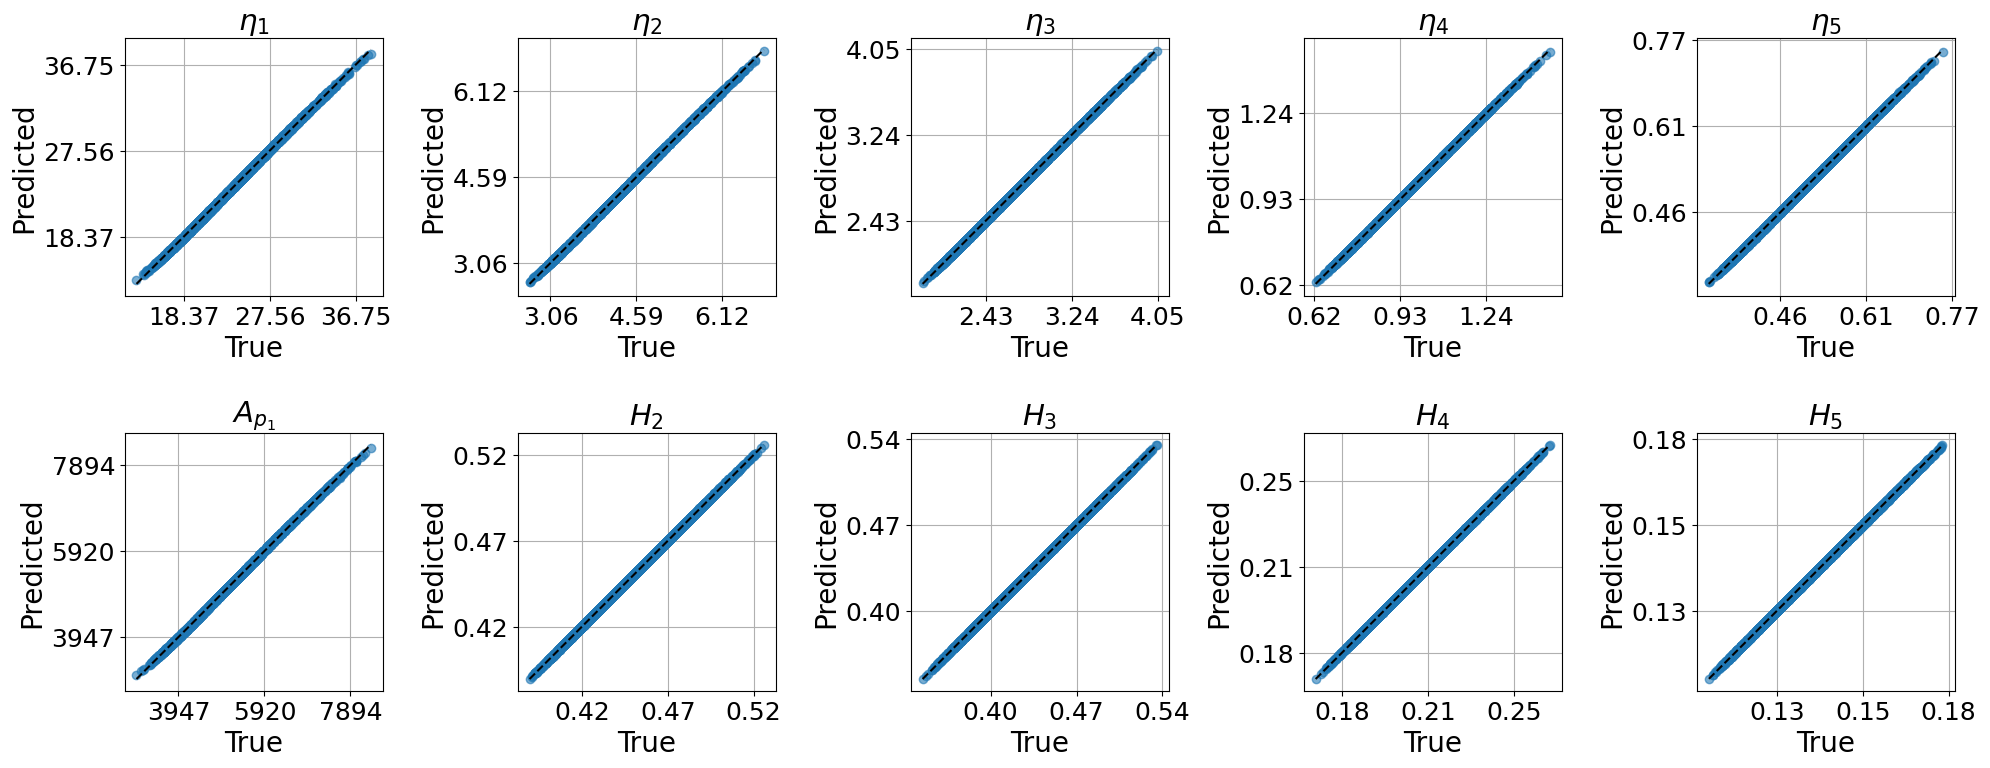

In [50]:
from matplotlib import ticker as mticker


peak_param_names = [r'$\eta_1$', r'$\eta_2$', r'$\eta_3$', r'$\eta_4$', r'$\eta_5$',
                    r'$A_{p_1}$', r'$H_2$', r'$H_3$', r'$H_4$', r'$H_5$']
plot_predictions(test_peak_arr, Peaks_pred, peak_param_names, savefig='../figures/peak_pred.pdf', ft=20)

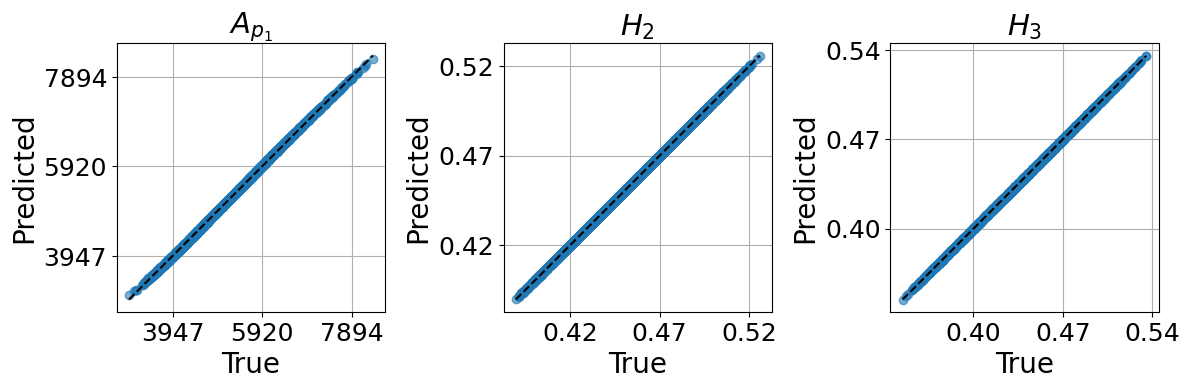

In [51]:

def plot_predictions_1r(true_params, pred_params, param_names=None, ft=16, n_major=3, savefig='figures/figure.pdf'):
    n_params = true_params.shape[1]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes = axes.flatten()
    
    if param_names is None:
        param_names = [f"$\theta_{i}$" for i in range(n_params)]

    pad_frac = 0.05
    for i in range(n_params):
        vmin = min(true_params[:, i].min(), pred_params[:, i].min())
        vmax = max(true_params[:, i].max(), pred_params[:, i].max())
        rng  = vmax - vmin
        lo   = vmin - pad_frac * rng
        hi   = vmax + pad_frac * rng

        step = (hi-lo) / n_major
        loc  = mticker.MultipleLocator(step)

        ax = axes[i] if n_params > 1 else axes

        if i==0:
            digits = 0                           # show three decimals everywhere
            fmt = mticker.StrMethodFormatter(f'{{x:.{digits}f}}')
            ax.xaxis.set_major_formatter(fmt)
            ax.yaxis.set_major_formatter(fmt)
        else:
            digits = 2                           # show one decimal everywhere
            fmt = mticker.StrMethodFormatter(f'{{x:.{digits}f}}')
            ax.xaxis.set_major_formatter(fmt)
            ax.yaxis.set_major_formatter(fmt)

        ax.plot(true_params[:, i], pred_params[:, i], 'o', alpha=0.6)
        ax.plot([true_params[:, i].min(), true_params[:, i].max()],
                [true_params[:, i].min(), true_params[:, i].max()], 'k--')
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

                # identical tick lines:
        ax.xaxis.set_major_locator(loc)
        ax.yaxis.set_major_locator(loc)
        ax.set_aspect("equal", adjustable="box")  # or set_box_aspect(1)
        ax.set_xlabel(f"True", fontsize=ft)
        ax.set_ylabel(f"Predicted", fontsize=ft)
        ax.tick_params(axis='both', which='major', labelsize=ft-1)
        ax.tick_params(axis='both', which='major', labelsize=ft-2)
        ax.set_title(param_names[i], fontsize=ft+1)
        ax.grid(True)
    
    plt.tight_layout()
    if savefig is not None:
        plt.savefig(savefig)
    plt.show()

plot_predictions_1r(test_peak_arr[:,5:8], Peaks_pred[:,5:8], peak_param_names[5:8], savefig='../figures/peak_pred_part.pdf', ft=20)

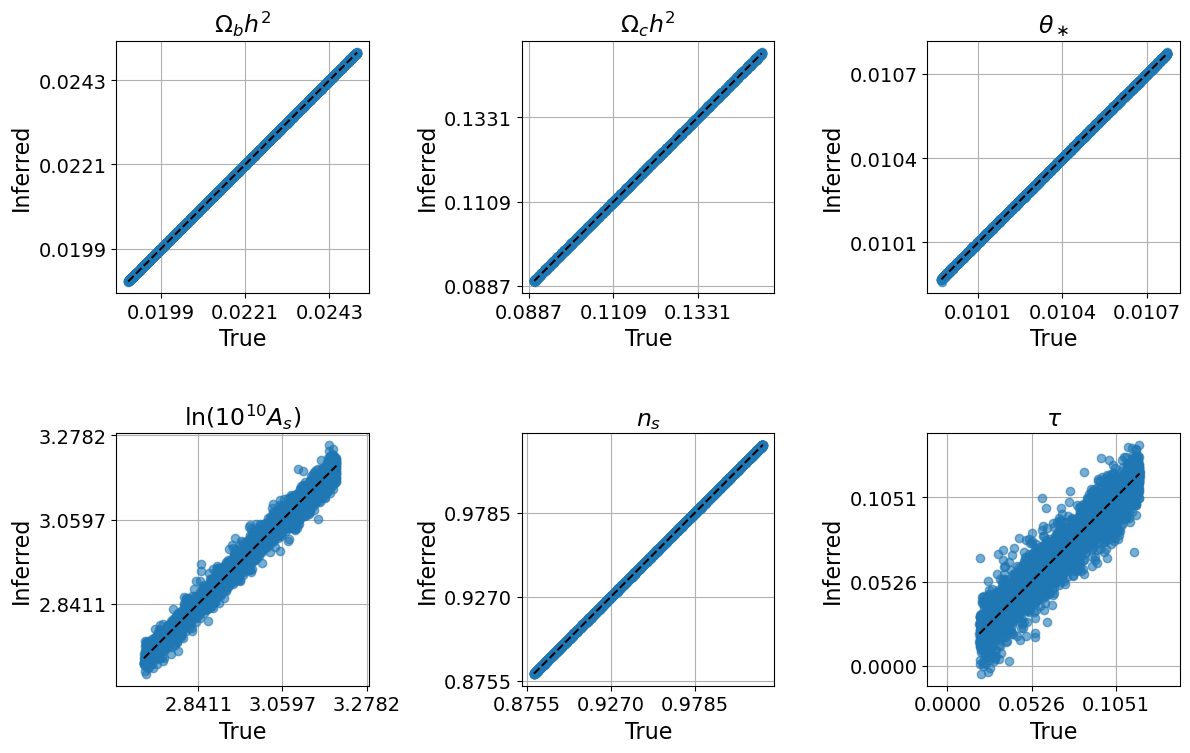

In [52]:
def plot_predictions(true_params, pred_params, param_names=None, ft=16, n_major=3, savefig=None):
    n_params = true_params.shape[1]
    fig, axes = plt.subplots(2, n_params//2, figsize=(2 * n_params, 8))
    axes = axes.flatten()
    
    if param_names is None:
        param_names = [f"$\\theta_{i}$" for i in range(n_params)]

    pad_frac = 0.05
    for i in range(n_params):
        vmin = min(true_params[:, i].min(), pred_params[:, i].min())
        vmax = max(true_params[:, i].max(), pred_params[:, i].max())
        rng  = vmax - vmin
        lo   = vmin - pad_frac * rng
        hi   = vmax + pad_frac * rng

        step = (hi-lo) / n_major
        loc  = mticker.MultipleLocator(step)

        ax = axes[i] if n_params > 1 else axes


        digits = 4                           # show three decimals everywhere
        fmt = mticker.StrMethodFormatter(f'{{x:.{digits}f}}')
        ax.xaxis.set_major_formatter(fmt)
        ax.yaxis.set_major_formatter(fmt)

        ax.plot(true_params[:, i], pred_params[:, i], 'o', alpha=0.6)
        ax.plot([true_params[:, i].min(), true_params[:, i].max()],
                [true_params[:, i].min(), true_params[:, i].max()], 'k--')
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

                # identical tick lines:
        ax.xaxis.set_major_locator(loc)
        ax.yaxis.set_major_locator(loc)
        ax.set_aspect("equal", adjustable="box")  # or set_box_aspect(1)
        ax.set_xlabel(f"True", fontsize=ft)
        ax.set_ylabel(f"Inferred", fontsize=ft)
        ax.tick_params(axis='both', which='major', labelsize=ft-1)
        ax.tick_params(axis='both', which='major', labelsize=ft-2)
        ax.set_title(param_names[i], fontsize=ft+1)
        ax.grid(True)
    
    plt.tight_layout()
    if savefig is not None:
        plt.savefig(savefig)
    plt.show()

plot_predictions(perturbed_LCDM_params, Params_inferred, param_names=param_names, ft=16, savefig='../figures/peak_inference.pdf')


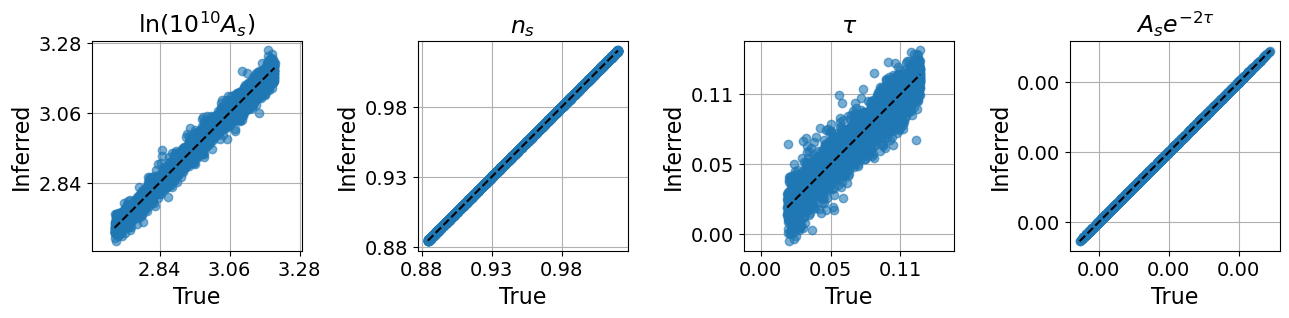

In [89]:
def plot_predictions_1r(true_params, pred_params, param_names=None, ft=16, n_major=3, savefig='figures/figure.pdf'):
    n_params = true_params.shape[1]
    fig, axes = plt.subplots(1, 4, figsize=(13, 4))
    axes = axes.flatten()
    
    if param_names is None:
        param_names = [f"$\theta_{i}$" for i in range(n_params)]

    pad_frac = 0.05

    true_overall_amplitude = 1e-10 * np.exp(perturbed_LCDM_params[:, 3]) * np.exp(-2 * perturbed_LCDM_params[:, 5])
    pred_overall_amplitude = 1e-10 * np.exp(Params_inferred[:, 3]) * np.exp(-2 * Params_inferred[:, 5])
    for i in range(n_params+1):
        if i < 3:
            vmin = min(true_params[:, i].min(), pred_params[:, i].min())
            vmax = max(true_params[:, i].max(), pred_params[:, i].max())
        else:
            vmin = min(true_overall_amplitude.min(), pred_overall_amplitude.min())
            vmax = max(true_overall_amplitude.max(), pred_overall_amplitude.max())
        rng  = vmax - vmin
        lo   = vmin - pad_frac * rng
        hi   = vmax + pad_frac * rng

        step = (hi-lo) / n_major
        loc  = mticker.MultipleLocator(step)

        ax = axes[i] if n_params > 1 else axes

        if i==0:
            digits = 2                           # show three decimals everywhere
            fmt = mticker.StrMethodFormatter(f'{{x:.{digits}f}}')
            ax.xaxis.set_major_formatter(fmt)
            ax.yaxis.set_major_formatter(fmt)
        else:
            digits = 2                           # show one decimal everywhere
            fmt = mticker.StrMethodFormatter(f'{{x:.{digits}f}}')
            ax.xaxis.set_major_formatter(fmt)
            ax.yaxis.set_major_formatter(fmt)

        if i < 3:

            ax.plot(true_params[:, i], pred_params[:, i], 'o', alpha=0.6)
            ax.plot([true_params[:, i].min(), true_params[:, i].max()],
                    [true_params[:, i].min(), true_params[:, i].max()], 'k--')
            ax.set_title(param_names[i], fontsize=ft+1)


        if i==3:
            ax = axes[3]
            ax.plot(true_overall_amplitude, pred_overall_amplitude, 'o', alpha=0.6)
            ax.plot([true_overall_amplitude.min(), true_overall_amplitude.max()],
                [true_overall_amplitude.min(), true_overall_amplitude.max()], 'k--')
            ax.set_title(r'$A_s e^{-2 \tau}$', fontsize=ft+1)
            
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

                # identical tick lines:
        ax.xaxis.set_major_locator(loc)
        ax.yaxis.set_major_locator(loc)
        ax.set_aspect("equal", adjustable="box")  # or set_box_aspect(1)
        ax.set_xlabel(f"True", fontsize=ft)
        ax.set_ylabel(f"Inferred", fontsize=ft)
        ax.tick_params(axis='both', which='major', labelsize=ft-1)
        ax.tick_params(axis='both', which='major', labelsize=ft-2)
        ax.grid(True)
    
    plt.tight_layout()
    if savefig is not None:
        plt.savefig(savefig)
    plt.show()

plot_predictions_1r(perturbed_LCDM_params[:,3:], Params_inferred[:,3:], param_names=param_names[3:], ft=16, savefig='../figures/peak_inference_part.pdf')

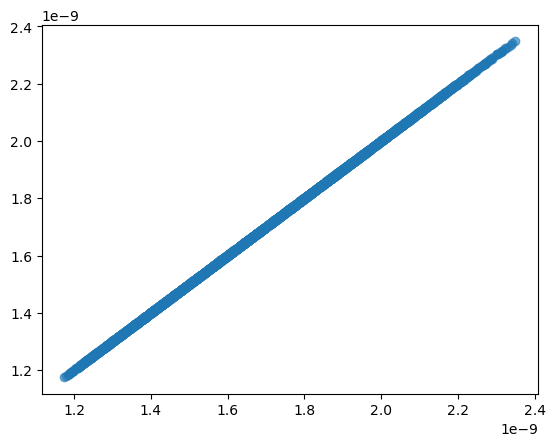

In [54]:
peak_pivot_LCDM = PolyCAMB_Peaks.forward_emulator(pivot_LCDM)
peak_pivot_ells, peak_pivot_Dell = peak_pos_hei(peak_pivot_LCDM.reshape(1,-1))

In [57]:
%timeit aux = PolyCAMB_Dl_TT.forward_emulator(perturbed_LCDM_params)

41.5 ms ± 267 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [58]:
pred_perturbed_LCDM_Dell_TT = PolyCAMB_Dl_TT.forward_emulator(perturbed_LCDM_params)
pred_pivot_LCDM_Dell_TT = PolyCAMB_Dl_TT.forward_emulator(pivot_LCDM)

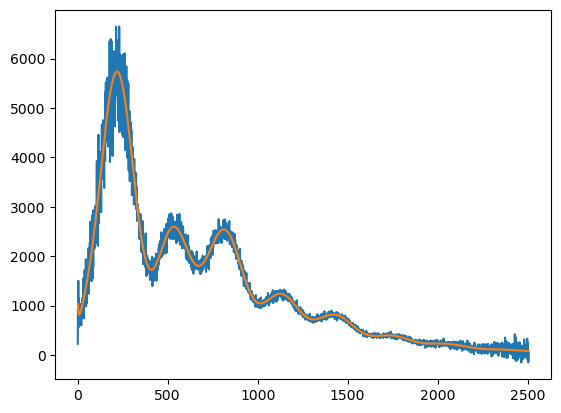

In [38]:
plt.plot(D_ell[:2507], label='Planck 2018')
plt.plot(true_pivot_Dell_TT[:2507], label='CAMB')

In [31]:
import numpy as np

# Path to your downloaded file
fname = "../planck_2018/COM_PowerSpect_CMB-TT-full_R3.01.txt"

# Load skipping commented header lines (those starting with '#')
data = np.loadtxt(fname, comments='#')

# Columns: ell, D_ell, sigma
ell = data[:, 0]
D_ell = data[:, 1]
err_m_D_ell = data[:, 2]
err_p_D_ell = data[:, 3]

print(ell.shape, D_ell.shape, err_m_D_ell.shape, err_p_D_ell.shape)

(2507,) (2507,) (2507,) (2507,)


/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_8804/972743118.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


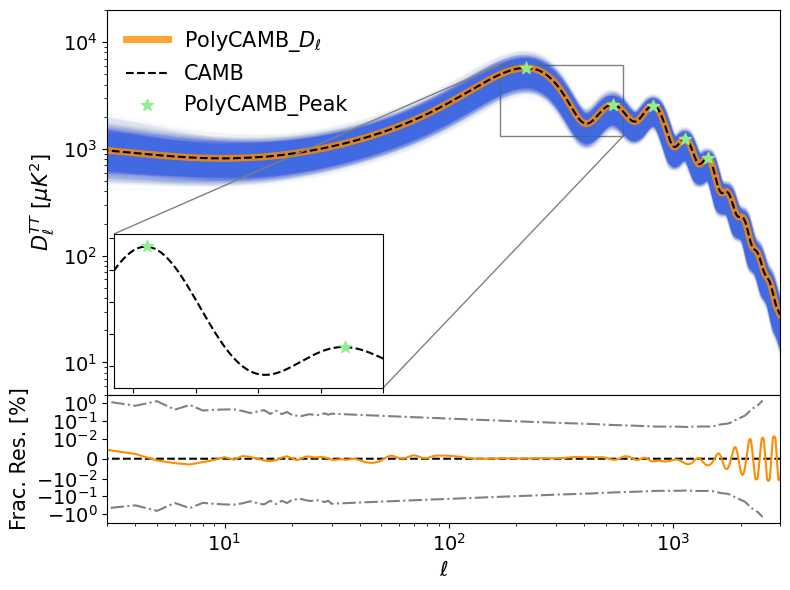

In [39]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt

color_ls = ['DarkOrange', 'RoyalBlue', 'ForestGreen', 'Crimson', 'Purple', 'Gray']
ftsize = 15

# residual_lower_1sigma = np.percentile(pred_perturbed_LCDM_Dell, 16, axis=0) - pred_pivot_LCDM_Dell[0]
# residual_upper_1sigma = np.percentile(pred_perturbed_LCDM_Dell, 84, axis=0) - pred_pivot_LCDM_Dell[0]

# residual_lower_2sigma = np.percentile(pred_perturbed_LCDM_Dell, 2.5, axis=0) - pred_pivot_LCDM_Dell[0]
# residual_upper_2sigma = np.percentile(pred_perturbed_LCDM_Dell, 97.5, axis=0) - pred_pivot_LCDM_Dell[0]

fig = plt.figure(figsize=(8, 6))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.0)

ax00 = fig.add_subplot(gs[0])
for i in range(N_samples):
    ax00.plot(ells, pred_perturbed_LCDM_Dell_TT[i], alpha=0.01,  color=color_ls[1])
ax00.plot(ells, pred_pivot_LCDM_Dell_TT, alpha=0.8, lw=5, color=color_ls[0], label=r'PolyCAMB_$D_\ell$')
ax00.plot(ells, true_pivot_Dell_TT, linestyle='--', color='black', label=r'CAMB')
ax00.scatter(peak_pivot_ells, peak_pivot_Dell, color='lightgreen', label=r'PolyCAMB_Peak', marker='*', s=80,zorder=2)
ax00.set_xscale('log')
ax00.set_yscale('log')
#ax00.set_xlabel(r'$\ell$')
ax00.set_xlim(3, 3000)
ax00.set_ylim(5,20000)
# D_ell is normalised C_ell
#plt.ylabel(r'$C_\ell\ell(\ell+1)/2\pi$')
ax00.set_ylabel(r'$D_\ell^{TT}$ [$\mu K^2$]', fontsize=ftsize)
ax00.legend(loc='upper left', fontsize=ftsize, frameon=False)


# Inset for zoomed region (as before)
segment_start = 170
segment_end = 600
main_y = true_pivot_Dell_TT[segment_start:segment_end]
y_min = np.min(main_y)
y_max = np.max(main_y)
margin = 0.1 * (y_max - y_min)
axins = inset_axes(ax00, width="40%", height="40%", loc='lower left')
axins.plot(ells, true_pivot_Dell_TT, linestyle='--', color='black')
axins.scatter(peak_pivot_ells, peak_pivot_Dell, color='lightgreen', marker='*', s=80,zorder=2)
axins.set_xlim(segment_start, segment_end)
axins.set_ylim(y_min - margin, y_max + margin)
axins.set_xticklabels([])
axins.set_yticklabels([])
mark_inset(ax00, axins, loc1=2, loc2=4, fc="none", ec="0.5")

ax10 = fig.add_subplot(gs[1], sharex=ax00)
ax10.plot(ells[:2507], -err_m_D_ell/true_pivot_Dell_TT[:2507], color='gray', linestyle='-.')
ax10.plot(ells[:2507], err_p_D_ell/true_pivot_Dell_TT[:2507], color='gray', linestyle='-.')
ax10.plot(ells, 0 * ells, color='black', linestyle='--')
ax10.plot(ells, (pred_pivot_LCDM_Dell_TT - true_pivot_Dell_TT) / true_pivot_Dell_TT * 100, color=color_ls[0]) 
# Use symlog scale - linear near zero, log for larger values
ax10.set_yscale('symlog', linthresh=0.01)  # Linear threshold at 0.01%
ax10.set_xlabel(r'$\ell$', fontsize=ftsize)
ax10.set_ylabel('Frac. Res. [%]', fontsize=ftsize)

# Set the fontsize for all tick labels and ticks
for ax in [ax00, ax10]:
    ax.tick_params(axis='both', which='major', labelsize=ftsize-1)
    ax.tick_params(axis='both', which='minor', labelsize=ftsize-1)
plt.tight_layout()
plt.savefig('../figures/poly_camb.png', dpi=600)
plt.show()

In [ ]:
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
# from matplotlib.gridspec import GridSpec
# import matplotlib.pyplot as plt

# color_ls = ['DarkOrange', 'RoyalBlue', 'ForestGreen', 'Crimson', 'Purple', 'Gray']
# ftsize = 15

# residual_lower_1sigma = np.percentile(pred_perturbed_LCDM_Dell, 16, axis=0) - pred_pivot_LCDM_Dell[0]
# residual_upper_1sigma = np.percentile(pred_perturbed_LCDM_Dell, 84, axis=0) - pred_pivot_LCDM_Dell[0]

# residual_lower_2sigma = np.percentile(pred_perturbed_LCDM_Dell, 2.5, axis=0) - pred_pivot_LCDM_Dell[0]
# residual_upper_2sigma = np.percentile(pred_perturbed_LCDM_Dell, 97.5, axis=0) - pred_pivot_LCDM_Dell[0]

# fig = plt.figure(figsize=(8, 8))
# gs = GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.0)

# ax00 = fig.add_subplot(gs[0])
# for i in range(N_samples):
#     ax00.plot(ells, pred_perturbed_LCDM_Dell[i], alpha=0.02,  color=color_ls[1])
# ax00.plot(ells, pred_pivot_LCDM_Dell[0], alpha=0.8, lw=5, color=color_ls[0], label=r'PolyCAMB_$D_\ell$')
# ax00.plot(ells, true_pivot_Dell_TT, linestyle='--', color='black', label=r'CAMB')
# ax00.scatter(peak_pivot_ells, peak_pivot_Dell, color='lightgreen', label=r'PolyCAMB_Peak', marker='*', s=80,zorder=2)
# ax00.set_xscale('log')
# ax00.set_yscale('log')
# #ax00.set_xlabel(r'$\ell$')
# ax00.set_xlim(3, 2500)
# # ax00.set_ylim(1,8000)
# # D_ell is normalised C_ell
# #plt.ylabel(r'$C_\ell\ell(\ell+1)/2\pi$')
# ax00.set_ylabel(r'$D_\ell^{TT}$ [$\mu K^2$]', fontsize=ftsize)
# ax00.legend(loc='upper left', fontsize=ftsize, frameon=False)

# ax10 = fig.add_subplot(gs[1], sharex=ax00)
# ax10.plot(ells, 0 * ells, color='black', linestyle='--')
# ax10.plot(ells, (pred_pivot_LCDM_Dell[0] - true_pivot_Dell_TT) / true_pivot_Dell_TT * 100, color=color_ls[0]) 
# ax10.set_xlabel(r'$\ell$', fontsize=ftsize)
# ax10.set_ylabel('Frac. Res. [%]', fontsize=ftsize)

# ax20 = fig.add_subplot(gs[2], sharex=ax00)
# ax20.fill_between(ells, residual_lower_1sigma, residual_upper_1sigma, color=color_ls[1], alpha=0.3, label='68% CI')
# ax20.fill_between(ells, residual_lower_2sigma, residual_upper_2sigma, color=color_ls[1], alpha=0.15, label='95% CI')
# ax20.legend(frameon=False, fontsize=ftsize, ncol=2)
# ax20.set_xlabel(r'$\ell$', fontsize=ftsize)
# ax20.set_ylabel('Res. [$\mu K^2$]', fontsize=ftsize)

# # Set the fontsize for all tick labels and ticks
# for ax in [ax00, ax10, ax20]:
#     ax.tick_params(axis='both', which='major', labelsize=ftsize-1)
#     ax.tick_params(axis='both', which='minor', labelsize=ftsize-1)
# plt.tight_layout()
# plt.savefig('figures/poly_camb.pdf', dpi=300)
# plt.show()

## Hu01 vs Z25

In [59]:
def peak2_over_peak1(ombh2, omch2, ns):
    om_m = ombh2 + omch2
    numer =  0.925 * om_m ** 0.18 * 2.4 ** (ns-1) 
    denomi = (1 + (ombh2/0.0164)**(12 * om_m**0.52))**0.2
    return numer / denomi

def peak3_over_peak1(ombh2, omch2, ns):
    om_m = ombh2 + omch2
    numer =  2.17 * om_m ** 0.59 * 3.6 ** (ns-1) 
    denomi = (1 + (ombh2/0.044)**2) * ( 1 + 1.63 * (1 - ombh2 / 0.071) * om_m )
    return numer / denomi

In [61]:
bounds = demo_bounds

In [62]:
length = 100
ombh2_ls = np.linspace(bounds['ombh2'][0], bounds['ombh2'][1], length) 
omch2_ls = np.linspace(bounds['omch2'][0], bounds['omch2'][1], length)
thetastar_ls = np.linspace(bounds['thetastar'][0], bounds['thetastar'][1], length)
ln10As_ls = np.linspace(bounds['ln_1e10_As'][0], bounds['ln_1e10_As'][1], length)
As_ls = np.exp(ln10As_ls) * 1e-10
ns_ls = np.linspace(bounds['ns'][0], bounds['ns'][1], length)
tau_ls = np.linspace(bounds['tau'][0], bounds['tau'][1], length)

In [63]:
aux_params = np.ones((length,6))
aux_params *= pivot_LCDM[np.newaxis,:]

aux_params_ombh2 = aux_params.copy()
aux_params_ombh2[:,0] = ombh2_ls
aux_params_omch2 = aux_params.copy()
aux_params_omch2[:,1] = omch2_ls
aux_params_thetastar = aux_params.copy()
aux_params_thetastar[:,2] = thetastar_ls
aux_params_As = aux_params.copy()
aux_params_As[:,3] = ln10As_ls
aux_params_ns = aux_params.copy()
aux_params_ns[:,4] = ns_ls
aux_params_tau = aux_params.copy()
aux_params_tau[:,5] = tau_ls

In [64]:
H2_H01_list = []
H3_H01_list = []

H2_H01_list.append(peak2_over_peak1(ombh2_ls, omch2, ns))
H2_H01_list.append(peak2_over_peak1(ombh2, omch2_ls, ns))
H2_H01_list.append(peak2_over_peak1(ombh2, omch2, ns) * np.ones(length))
H2_H01_list.append(peak2_over_peak1(ombh2, omch2, ns) * np.ones(length))
H2_H01_list.append(peak2_over_peak1(ombh2, omch2, ns_ls) )
H2_H01_list.append(peak2_over_peak1(ombh2, omch2, ns) * np.ones(length))

H3_H01_list.append(peak3_over_peak1(ombh2_ls, omch2, ns))
H3_H01_list.append(peak3_over_peak1(ombh2, omch2_ls, ns))
H3_H01_list.append(peak3_over_peak1(ombh2, omch2, ns) * np.ones(length))
H3_H01_list.append(peak3_over_peak1(ombh2, omch2, ns) * np.ones(length))
H3_H01_list.append(peak3_over_peak1(ombh2, omch2, ns_ls) )
H3_H01_list.append(peak3_over_peak1(ombh2, omch2, ns) * np.ones(length))

In [65]:
def obtain_Z25_H2_H3(aux_params):
    aux = PolyCAMB_Peaks.forward_emulator(aux_params)
    H2 = aux[:, 6]
    H3 = aux[:, 7]
    return H2, H3

H2_Z25_list = []
H3_Z25_list = []

H2, H3 = obtain_Z25_H2_H3(aux_params_ombh2)
H2_Z25_list.append(H2)
H3_Z25_list.append(H3)

H2, H3 = obtain_Z25_H2_H3(aux_params_omch2)
H2_Z25_list.append(H2)
H3_Z25_list.append(H3)

H2, H3 = obtain_Z25_H2_H3(aux_params_thetastar)
H2_Z25_list.append(H2)
H3_Z25_list.append(H3)

H2, H3 = obtain_Z25_H2_H3(aux_params_As)
H2_Z25_list.append(H2)
H3_Z25_list.append(H3)

H2, H3 = obtain_Z25_H2_H3(aux_params_ns)
H2_Z25_list.append(H2)
H3_Z25_list.append(H3)

H2, H3 = obtain_Z25_H2_H3(aux_params_tau)
H2_Z25_list.append(H2)
H3_Z25_list.append(H3)

In [66]:
def obtain_CAMB_H2_H3(aux_params):
    Dell_list = generate_CAMB_aps_TT(aux_params)
    aux_ells = np.arange(Dell_list.shape[1])
    Peak_list = peak_summary(aux_ells, Dell_list, 5)
    H2 = Peak_list[:, 6]
    H3 = Peak_list[:, 7]
    return H2, H3

H2_CAMB_list = []
H3_CAMB_list = []

H2, H3 = obtain_CAMB_H2_H3(aux_params_ombh2)
H2_CAMB_list.append(H2)
H3_CAMB_list.append(H3)

H2, H3 = obtain_CAMB_H2_H3(aux_params_omch2)
H2_CAMB_list.append(H2)
H3_CAMB_list.append(H3)

H2, H3 = obtain_CAMB_H2_H3(aux_params_thetastar)
H2_CAMB_list.append(H2)
H3_CAMB_list.append(H3)

H2, H3 = obtain_CAMB_H2_H3(aux_params_As)
H2_CAMB_list.append(H2)
H3_CAMB_list.append(H3)

H2, H3 = obtain_CAMB_H2_H3(aux_params_ns)
H2_CAMB_list.append(H2)
H3_CAMB_list.append(H3)

H2, H3 = obtain_CAMB_H2_H3(aux_params_tau)
H2_CAMB_list.append(H2)
H3_CAMB_list.append(H3)

100%|██████████| 100/100 [00:00<00:00, 25483.35it/s]


/var/folders/r5/jq1d5z7917582lhx9y8r4rj80000gn/T/ipykernel_8804/651301323.py:64: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


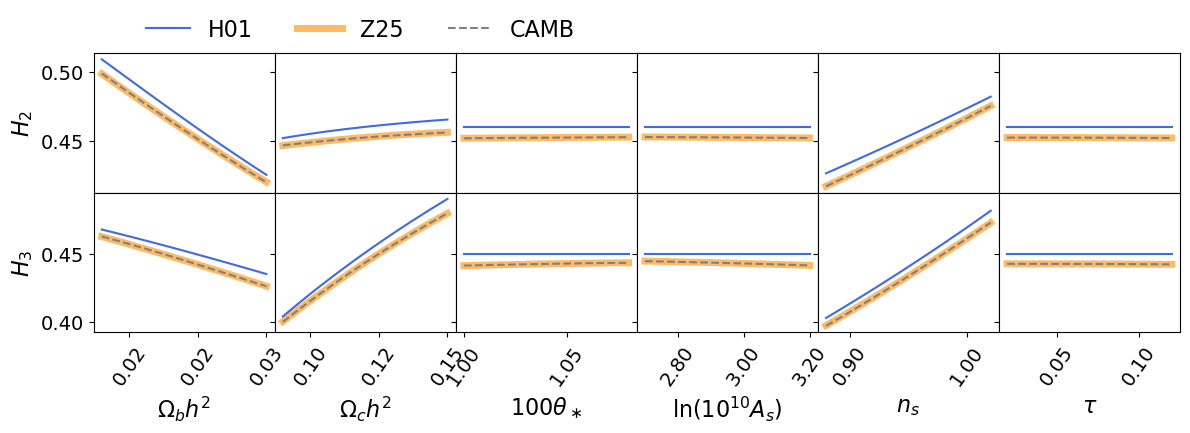

In [72]:

fig, ax = plt.subplots(nrows=2, ncols=6,  
                         figsize=(12, 4),
                         sharey='row', 
                         sharex='col',     
                         gridspec_kw={'wspace': 0.0, 'hspace': 0.0},
                         constrained_layout=True)

thetastar_ls_100 = np.array(thetastar_ls) * 100

xs_list = [ombh2_ls, omch2_ls, thetastar_ls_100, ln10As_ls, ns_ls,
        tau_ls ]
xs_labels = [r'$\Omega_b h^2$', r'$\Omega_c h^2$', r'$100\theta_\ast$', r'$\ln(10^{10}A_s)$', r'$n_s$', r'$\tau$']

digits = 2                           # show three decimals everywhere
fmt = mticker.StrMethodFormatter(f'{{x:.{digits}f}}')


ftsize = 16

for i in range(6):
    xs = xs_list[i]
    xs_label = xs_labels[i]
    model_hei2 = H2_H01_list[i]
    pred_hei2 = H2_Z25_list[i]
    model_hei3 = H3_H01_list[i]
    pred_hei3 = H3_Z25_list[i]
    true_h2 = H2_CAMB_list[i]
    true_h3 = H3_CAMB_list[i]

    Emu_line, = ax[0,i].plot(xs, pred_hei2, color=color_ls[0], lw=5, alpha=0.6)
    model_line, = ax[0,i].plot(xs, model_hei2, color=color_ls[1])
    true_line, = ax[0,i].plot(xs, true_h2, color='gray', linestyle='--')
    #ax[0,i].set_xlabel(xs_label)


    #ax[i, 0].set_ylim(5200, 7000)
    ax[1,i].plot(xs, pred_hei3, color=color_ls[0], lw=5, alpha=0.6)
    ax[1,i].plot(xs, model_hei3, color=color_ls[1])
    ax[1,i].plot(xs, true_h3, color='gray', linestyle='--')
    ax[1,i].set_xlabel(xs_label, fontsize=ftsize)
    ax[1,i].tick_params(axis='x', rotation=55)
    if i!=2:
        ax[1,i].xaxis.set_major_formatter(fmt)
    if i==0:
        ax[0,i].set_ylabel(r'$H_2$', fontsize=ftsize)
        ax[1,i].set_ylabel(r'$H_3$', fontsize=ftsize)

    ax[0,i].tick_params(axis='both', which='major', labelsize=ftsize-2)
    ax[0,i].tick_params(axis='both', which='minor', labelsize=ftsize-2)
    ax[1,i].tick_params(axis='both', which='major', labelsize=ftsize-2)
    ax[1,i].tick_params(axis='both', which='minor', labelsize=ftsize-2)
# Create figure-level legend
fig.legend(
    [model_line, Emu_line, true_line],  # Handles from your plots
    ['H01', 'Z25', 'CAMB'],  # Labels
    ncol=3,                # Number of columns
    loc='upper right',        # Anchor point position
    bbox_to_anchor=(0.5, 1.1),  # Position in figure coordinates
    bbox_transform=fig.transFigure , # Use figure coordinate system
    fontsize=ftsize,
    frameon=False
)

plt.tight_layout()
plt.savefig('../figures/H2_H3.pdf', bbox_inches='tight')
plt.show()


    

In [73]:
from sklearn.metrics import mean_squared_error
H2_CAMB_list = np.array(H2_CAMB_list)
H3_CAMB_list = np.array(H3_CAMB_list)
H2_Z25_list = np.array(H2_Z25_list)
H3_Z25_list = np.array(H3_Z25_list)
H2_H01_list = np.array(H2_H01_list)
H3_H01_list = np.array(H3_H01_list)
print("RMSfE of H2_Z25:", np.sqrt(np.mean(( H2_Z25_list /H2_CAMB_list - 1. )**2)))
print("RMSfE of H3_Z25:", np.sqrt(mean_squared_error( H3_Z25_list/H3_CAMB_list, np.ones_like(H3_CAMB_list) )))

print("RMSfE of H2_H01:", np.sqrt(mean_squared_error( H2_H01_list/H2_CAMB_list, np.ones_like(H2_CAMB_list) )))
print("RMSfE of H3_H01:", np.sqrt(mean_squared_error( H3_H01_list/H3_CAMB_list, np.ones_like(H3_CAMB_list) )))


RMSfE of H2_Z25: 0.00020002876765715184
RMSfE of H3_Z25: 0.00018714391766301567
RMSfE of H2_H01: 0.0172705699485504
RMSfE of H3_H01: 0.016340628549598012


## Symbolic analysis

In [74]:
import math
from itertools import product
import sympy as sp


def taylor_multivariate(expr, vars_, point, order=2):
    series = 0
    subs0 = dict(zip(vars_, point))

    for powers in product(range(order + 1), repeat=len(vars_)):
        if sum(powers) > order:
            continue

        term = expr
        denom = 1
        for v, k in zip(vars_, powers):
            if k:
                term = sp.diff(term, v, k)
                denom *= math.factorial(k)
        term = term.subs(subs0) / denom

        for v, k, p0 in zip(vars_, powers, point):
            if k:
                term *= (v - p0) ** k

        series += term

    return sp.expand(series)

def peak2_over_peak1_expr():
    ombh2, omch2, ns = sp.symbols('ombh2 omch2 ns')
    om_m = ombh2 + omch2
    expr = (
        0.925 * om_m ** sp.Rational(18, 100) * 2.4 ** (ns - 1)
        / (1 + (ombh2 / 0.0164) ** (12 * om_m ** sp.Rational(52, 100))) ** sp.Rational(1, 5)
    )
    return expr, (ombh2, omch2, ns)

def peak3_over_peak1_expr():
    """
    Return a SymPy expression for the empirical third-to-first-acoustic-peak
    height ratio, together with its symbol tuple (ombh2, omch2, ns).

    H₃ / H₁  ≡  2.17 · Ωₘ⁰·⁵⁹ · 3.6^(n_s – 1)
                ───────────────────────────────────
                (1 + (Ω_bh² / 0.044)²) · (1 + 1.63·(1 − Ω_bh²/0.071)·Ωₘ)
    """
    # define symbols
    ombh2, omch2, ns = sp.symbols('ombh2 omch2 ns')

    # shorthand
    om_m = ombh2 + omch2

    # build the expression
    expr = (
        2.17 * om_m**sp.Rational(59, 100) * 3.6**(ns - 1)
        / (
            (1 + (ombh2 / 0.044)**2)
            * (1 + 1.63 * (1 - ombh2 / 0.071) * om_m)
        )
    )

    return expr, (ombh2, omch2, ns)


def peak2_over_peak1_taylor(point, order=2):
    expr, vars_ = peak2_over_peak1_expr()
    return taylor_multivariate(expr, vars_, point, order)

def peak3_over_peak1_taylor(point, order=2):
    expr, vars_ = peak3_over_peak1_expr()
    return taylor_multivariate(expr, vars_, point, order)




In [75]:
# Symbolic expressions for the peak observables 
forward_expressions = PolyCAMB_Peaks.generate_forward_symb_emu()

In [76]:
from sympy import latex

In [77]:
aux = PolyCAMB_Peaks.scaler_X.mean_
H2_model_taylor_series = peak2_over_peak1_taylor((aux[0], aux[1], aux[4]), order=2)
latex(H2_model_taylor_series)

'0.17606588407123 ns^{2} - 12.2199790663312 ns ombh_{2} + 0.215553257071264 ns omch_{2} + 0.310668805688802 ns + 160.689588187445 ombh_{2}^{2} - 77.2889360997792 ombh_{2} omch_{2} - 0.144902384434557 ombh_{2} - 1.58789676762029 omch_{2}^{2} + 2.1228909065521 omch_{2} + 0.133800190339889'

In [78]:
from sympy import latex
print("H_2 expression generated by MomentEmu:")
latex(forward_expressions[6])

H_2 expression generated by MomentEmu:


'174.522623353818 x_{1}^{2} - 46.1660549632742 x_{1} x_{2} - 37.4586336669632 x_{1} x_{3} + 0.0941622269403135 x_{1} x_{4} - 9.73013152933159 x_{1} x_{5} + 0.280736782119067 x_{1} x_{6} - 5.75666928953032 x_{1} - 1.26102635787564 x_{2}^{2} + 9.49648910699276 x_{2} x_{3} - 0.00729623886663313 x_{2} x_{4} + 0.2565522486446 x_{2} x_{5} - 0.0511375525055624 x_{2} x_{6} + 1.17580117875878 x_{2} - 475.753698237136 x_{3}^{2} - 0.357410626716438 x_{3} x_{4} + 1.3085761777137 x_{3} x_{5} + 1.77471971708627 x_{3} x_{6} + 10.3159434585867 x_{3} - 0.000762280495560644 x_{4}^{2} + 0.000727166501932481 x_{4} x_{5} + 0.000161580096935498 x_{4} x_{6} + 0.00492190212296769 x_{4} + 0.161119642174306 x_{5}^{2} - 0.00377615332178335 x_{5} x_{6} + 0.281817645417529 x_{5} - 0.0364103986305342 x_{6}^{2} - 0.0136949608984321 x_{6} + 0.178755456284975'

In [79]:
print("H_3 expression generated by MomentEmu:")
latex(forward_expressions[7])

H_3 expression generated by MomentEmu:


'- 82.6986360752843 x_{1}^{2} - 18.8813732362875 x_{1} x_{2} - 47.0990012539629 x_{1} x_{3} + 0.10255303178189 x_{1} x_{4} - 6.51892665930304 x_{1} x_{5} + 0.272383721680154 x_{1} x_{6} + 6.25766861540943 x_{1} - 3.95688396802101 x_{2}^{2} + 39.7297581480071 x_{2} x_{3} - 0.0998054965579386 x_{2} x_{4} + 1.44445428527516 x_{2} x_{5} - 0.0775567311982847 x_{2} x_{6} + 1.20277204973799 x_{2} - 1294.10395308065 x_{3}^{2} + 2.22701018550434 x_{3} x_{4} + 3.12771065706433 x_{3} x_{5} + 0.192410370111168 x_{3} x_{6} + 16.0984988250204 x_{3} - 0.00331439542043698 x_{4}^{2} - 0.00494462582130763 x_{4} x_{5} + 0.00048288269125785 x_{4} x_{6} + 0.00427431290662429 x_{4} + 0.297575772466582 x_{5}^{2} - 0.00592670198887256 x_{5} x_{6} - 0.0668871312596684 x_{5} - 0.0461428410759362 x_{6}^{2} + 0.0076464520994968 x_{6} - 0.0375308499709019'

In [80]:
aux = PolyCAMB_Peaks.scaler_X.mean_
H3_model_taylor_series = peak3_over_peak1_taylor((aux[0], aux[1], aux[4]), order=2)
latex(H3_model_taylor_series)

'0.364122477284087 ns^{2} - 6.9280070785711 ns ombh_{2} + 1.81072609353335 ns omch_{2} - 0.188177089687104 ns - 74.0434910745754 ombh_{2}^{2} - 22.219228921892 ombh_{2} omch_{2} + 7.09726817777809 ombh_{2} - 4.03344544239522 omch_{2}^{2} + 1.15025859972421 omch_{2} + 0.0907643606091795'

In [ ]:
expr, _ = peak2_over_peak1_expr()
latex(expr)

'\\frac{0.925 {2.4}^{ns - 1} \\left(ombh_{2} + omch_{2}\\right)^{\\frac{9}{50}}}{\\sqrt[5]{\\left(60.9756097560976 ombh_{2}\\right)^{12 \\left(ombh_{2} + omch_{2}\\right)^{\\frac{13}{25}}} + 1}}'

In [ ]:
%timeit aux = PolyCAMB_Peaks.forward_emulator(pivot_LCDM)

97.7 μs ± 318 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
